# 🏏 IPL Exploratory Data Analysis

## 📊 Project Overview

This project performs Exploratory Data Analysis (EDA) on Indian Premier League (IPL) match and ball-by-ball delivery data.

The analysis explores:

* 🏆 Team Performance
* 🪙 Toss Impact
* 🏏 Batting Performance
* 🎯 Bowling Performance
* 📈 Match Statistics
* ⚡ Powerplay Analysis
* 💥 Death Overs Analysis

### 🎯 Objective

The objective of this project is to discover meaningful insights and patterns from IPL data using Python, Pandas, Matplotlib, and Seaborn.


## 1. 📚 Import Libraries


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. 📂 Load the Datasets


In [4]:
# Load datasets
matches = pd.read_csv("data/matches.csv")
deliveries = pd.read_csv("data/deliveries.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


## 3. 🔍 Dataset Understanding and Overview


In [5]:
print("Matches Shape:", matches.shape)
print("Deliveries Shape:", deliveries.shape)

Matches Shape: (1095, 20)
Deliveries Shape: (260920, 17)


In [6]:
# Display first 5 rows of matches dataset
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [7]:
# Display first 5 rows of deliveries dataset
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [8]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [9]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

## 4. 🧹 Data Cleaning and Preprocessing


In [10]:
# Check missing values in matches dataset
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [11]:
# Check missing values in deliveries dataset
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [12]:
# Check duplicate rows in matches dataset
print("Matches Duplicate Rows:", matches.duplicated().sum())

# Check duplicate rows in deliveries dataset
print("Deliveries Duplicate Rows:", deliveries.duplicated().sum())

Matches Duplicate Rows: 0
Deliveries Duplicate Rows: 0


In [13]:
print("MATCHES DATASET COLUMNS:")
print(matches.columns.tolist())

print("\nDELIVERIES DATASET COLUMNS:")
print(deliveries.columns.tolist())

MATCHES DATASET COLUMNS:
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

DELIVERIES DATASET COLUMNS:
['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


In [14]:
# Convert date column to datetime format
matches['date'] = pd.to_datetime(matches['date'])

# Check the data type
print(matches['date'].dtype)

datetime64[ns]


In [15]:
print(matches['season'].unique())

['2007/08' '2009' '2009/10' '2011' '2012' '2013' '2014' '2015' '2016'
 '2017' '2018' '2019' '2020/21' '2021' '2022' '2023' '2024']


In [16]:
print("Total Seasons:", matches['season'].nunique())

Total Seasons: 17


In [17]:
matches[matches['city'].isnull()][['venue', 'city']].head(10)

,venue,city
399,Sharjah Cricket Stadium,NaN
402,Dubai International Cricket Stadium,NaN
403,Dubai International Cricket Stadium,NaN
404,Sharjah Cricket Stadium,NaN
406,Sharjah Cricket Stadium,NaN
407,Dubai International Cricket Stadium,NaN
408,Sharjah Cricket Stadium,NaN
409,Dubai International Cricket Stadium,NaN
410,Dubai International Cricket Stadium,NaN
413,Sharjah Cricket Stadium,NaN


In [18]:
matches[matches['city'].isnull()]['venue'].value_counts()

venue
Dubai International Cricket Stadium    33
Sharjah Cricket Stadium                18
Name: count, dtype: int64

In [19]:
# Fill missing city values based on venue

matches.loc[
    matches['venue'] == 'Dubai International Cricket Stadium',
    'city'
] = 'Dubai'

matches.loc[
    matches['venue'] == 'Sharjah Cricket Stadium',
    'city'
] = 'Sharjah'

In [20]:
print("Missing city values:", matches['city'].isnull().sum())

Missing city values: 0


In [21]:
matches[matches['winner'].isnull()][
    ['season', 'date', 'team1', 'team2', 'result', 'winner']
]

,season,date,team1,team2,result,winner
241,2011,2011-05-21,Delhi Daredevils,Pune Warriors,no result,NaN
485,2015,2015-04-29,Royal Challengers Bangalore,Rajasthan Royals,no result,NaN
511,2015,2015-05-17,Royal Challengers Bangalore,Delhi Daredevils,no result,NaN
744,2019,2019-04-30,Royal Challengers Bangalore,Rajasthan Royals,no result,NaN
994,2023,2023-05-03,Lucknow Super Giants,Chennai Super Kings,no result,NaN


In [22]:
matches[matches['player_of_match'].isnull()][
    ['season', 'team1', 'team2', 'result', 'winner', 'player_of_match']
]

,season,team1,team2,result,winner,player_of_match
241,2011,Delhi Daredevils,Pune Warriors,no result,NaN,NaN
485,2015,Royal Challengers Bangalore,Rajasthan Royals,no result,NaN,NaN
511,2015,Royal Challengers Bangalore,Delhi Daredevils,no result,NaN,NaN
744,2019,Royal Challengers Bangalore,Rajasthan Royals,no result,NaN,NaN
994,2023,Lucknow Super Giants,Chennai Super Kings,no result,NaN,NaN


In [23]:
matches[matches['result_margin'].isnull()][
    ['season', 'team1', 'team2', 'result', 'result_margin']
]

,season,team1,team2,result,result_margin
66,2009,Kolkata Knight Riders,Rajasthan Royals,tie,NaN
130,2009/10,Chennai Super Kings,Kings XI Punjab,tie,NaN
241,2011,Delhi Daredevils,Pune Warriors,no result,NaN
328,2013,Sunrisers Hyderabad,Royal Challengers Bangalore,tie,NaN
342,2013,Royal Challengers Bangalore,Delhi Daredevils,tie,NaN
416,2014,Kolkata Knight Riders,Rajasthan Royals,tie,NaN
475,2015,Rajasthan Royals,Kings XI Punjab,tie,NaN
485,2015,Royal Challengers Bangalore,Rajasthan Royals,no result,NaN
511,2015,Royal Challengers Bangalore,Delhi Daredevils,no result,NaN
610,2017,Gujarat Lions,Mumbai Indians,tie,NaN


In [24]:
matches[matches['target_runs'].isnull()][
    ['season', 'team1', 'team2', 'result', 
     'target_runs', 'target_overs', 'method']
]

,season,team1,team2,result,target_runs,target_overs,method
241,2011,Delhi Daredevils,Pune Warriors,no result,NaN,NaN,NaN
485,2015,Royal Challengers Bangalore,Rajasthan Royals,no result,NaN,NaN,NaN
994,2023,Lucknow Super Giants,Chennai Super Kings,no result,NaN,NaN,NaN


In [25]:
print(matches['method'].value_counts(dropna=False))

method
NaN    1074
D/L      21
Name: count, dtype: int64


In [26]:
matches['method'] = matches['method'].fillna('Normal')

In [27]:
print(matches['method'].value_counts())

method
Normal    1074
D/L         21
Name: count, dtype: int64


In [28]:
print(deliveries['extras_type'].value_counts(dropna=False))

extras_type
NaN        246795
wides        8380
legbyes      4001
noballs      1069
byes          673
penalty         2
Name: count, dtype: int64


In [29]:
# Replace missing extras_type with 'No Extras'
deliveries['extras_type'] = deliveries['extras_type'].fillna('No Extras')

In [30]:
print(deliveries['extras_type'].value_counts())

extras_type
No Extras    246795
wides          8380
legbyes        4001
noballs        1069
byes            673
penalty           2
Name: count, dtype: int64


In [31]:
print("Total wicket events:", deliveries['is_wicket'].sum())

Total wicket events: 12950


In [32]:
print(deliveries['dismissal_kind'].value_counts(dropna=False))

dismissal_kind
NaN                      247970
caught                     8063
bowled                     2212
run out                    1114
lbw                         800
caught and bowled           367
stumped                     358
retired hurt                 15
hit wicket                   15
obstructing the field         3
retired out                   3
Name: count, dtype: int64


In [33]:
print("MATCHES MISSING VALUES:")
print(matches.isnull().sum())

print("\n" + "="*50 + "\n")

print("DELIVERIES MISSING VALUES:")
print(deliveries.isnull().sum())

MATCHES MISSING VALUES:
id                  0
season              0
city                0
date                0
match_type          0
player_of_match     5
venue               0
team1               0
team2               0
toss_winner         0
toss_decision       0
winner              5
result              0
result_margin      19
target_runs         3
target_overs        3
super_over          0
method              0
umpire1             0
umpire2             0
dtype: int64


DELIVERIES MISSING VALUES:
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type              0
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


## 5. 🏏 General IPL Analysis


In [34]:
print("=" * 50)
print("IPL DATASET OVERVIEW")
print("=" * 50)

print("\nTotal Matches:", matches.shape[0])
print("Total Deliveries:", deliveries.shape[0])
print("Total Seasons:", matches['season'].nunique())
print("Total Teams:", len(set(matches['team1']).union(set(matches['team2']))))
print("Total Venues:", matches['venue'].nunique())
print("Total Cities:", matches['city'].nunique())

IPL DATASET OVERVIEW

Total Matches: 1095
Total Deliveries: 260920
Total Seasons: 17
Total Teams: 19
Total Venues: 58
Total Cities: 36


## 6. 📅 Season Analysis


In [35]:
# Count matches played in each season
matches_per_season = matches['season'].value_counts().sort_index()

print(matches_per_season)

season
2007/08    58
2009       57
2009/10    60
2011       73
2012       74
2013       76
2014       60
2015       59
2016       60
2017       59
2018       60
2019       60
2020/21    60
2021       60
2022       74
2023       74
2024       71
Name: count, dtype: int64


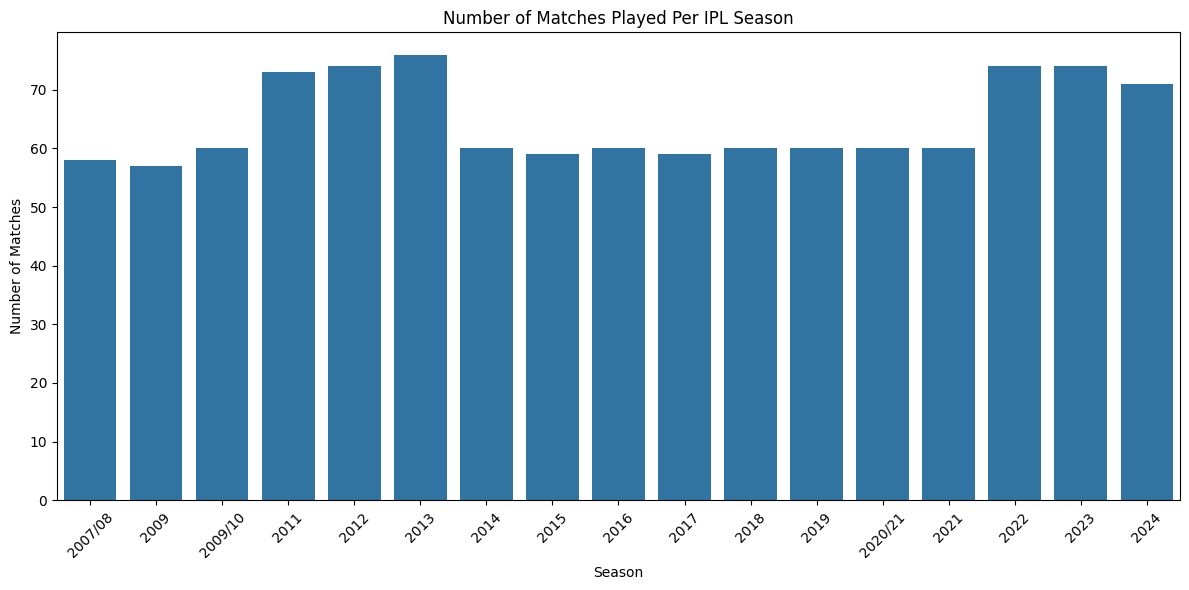

In [36]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=matches_per_season.index,
    y=matches_per_season.values
)

plt.title("Number of Matches Played Per IPL Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 7. 🏟️ City and Venue Analysis


In [37]:
matches_per_city = matches['city'].value_counts()

print(matches_per_city.head(10))

city
Mumbai        173
Kolkata        93
Delhi          90
Chennai        85
Hyderabad      77
Bangalore      65
Chandigarh     61
Jaipur         57
Pune           51
Dubai          46
Name: count, dtype: int64


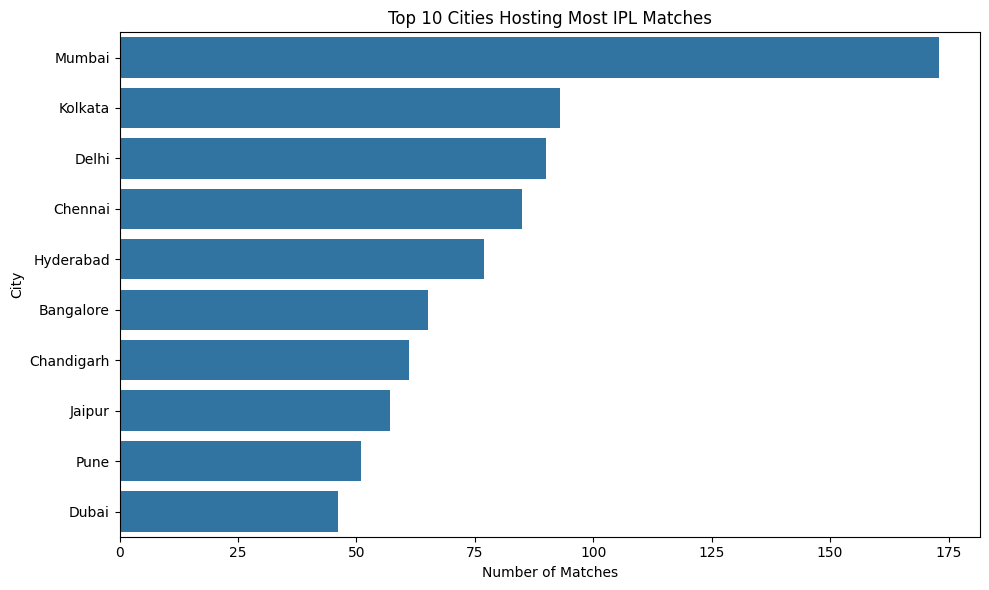

In [38]:
# Top 10 cities with most IPL matches
top_10_cities = matches_per_city.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_cities.values,
    y=top_10_cities.index
)

plt.title("Top 10 Cities Hosting Most IPL Matches")
plt.xlabel("Number of Matches")
plt.ylabel("City")

plt.tight_layout()
plt.show()

In [39]:
matches_per_venue = matches['venue'].value_counts()

print(matches_per_venue.head(10))

venue
Eden Gardens                                  77
Wankhede Stadium                              73
M Chinnaswamy Stadium                         65
Feroz Shah Kotla                              60
Rajiv Gandhi International Stadium, Uppal     49
MA Chidambaram Stadium, Chepauk               48
Sawai Mansingh Stadium                        47
Dubai International Cricket Stadium           46
Wankhede Stadium, Mumbai                      45
Punjab Cricket Association Stadium, Mohali    35
Name: count, dtype: int64


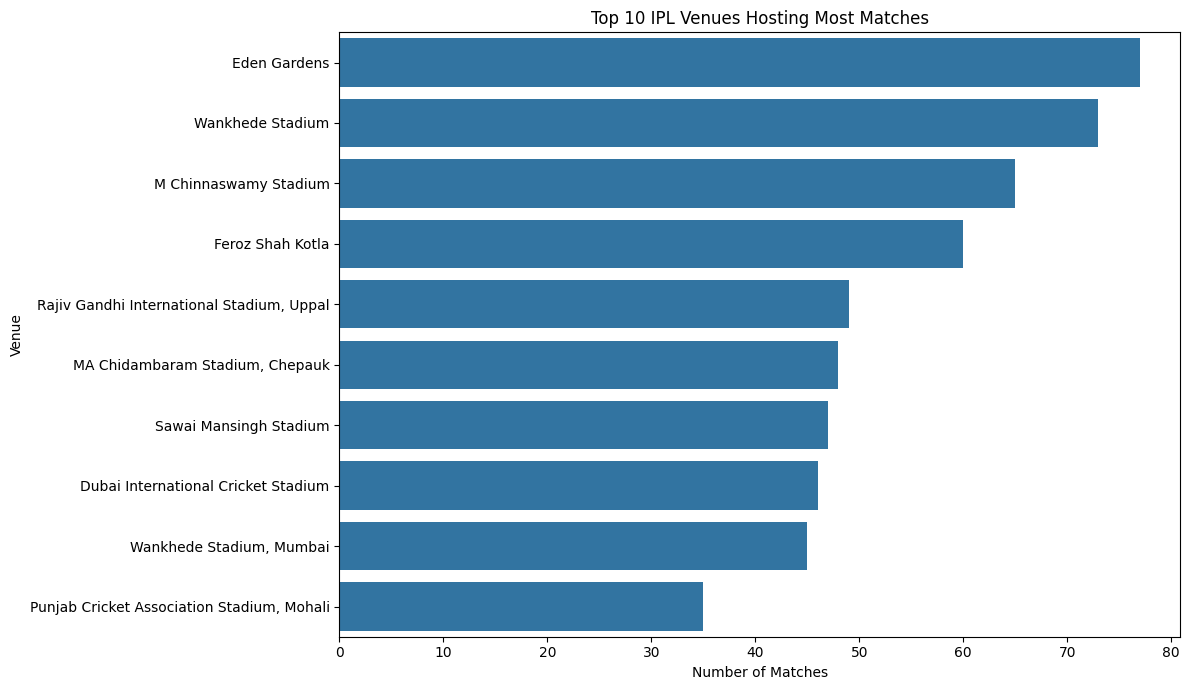

In [40]:
# Top 10 venues hosting the most IPL matches
top_10_venues = matches_per_venue.head(10)

plt.figure(figsize=(12, 7))

sns.barplot(
    x=top_10_venues.values,
    y=top_10_venues.index
)

plt.title("Top 10 IPL Venues Hosting Most Matches")
plt.xlabel("Number of Matches")
plt.ylabel("Venue")

plt.tight_layout()
plt.show()

## 8. 🏆 Team Performance Analysis


In [41]:
team_wins = matches['winner'].value_counts()

print(team_wins)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    116
Rajasthan Royals               112
Sunrisers Hyderabad             88
Kings XI Punjab                 88
Delhi Daredevils                67
Delhi Capitals                  48
Deccan Chargers                 29
Gujarat Titans                  28
Punjab Kings                    24
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
Name: count, dtype: int64


In [42]:
team_name_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}

In [43]:
team_columns = [
    'team1',
    'team2',
    'toss_winner',
    'winner'
]

for column in team_columns:
    matches[column] = matches[column].replace(team_name_mapping)

In [44]:
delivery_team_columns = [
    'batting_team',
    'bowling_team'
]

for column in delivery_team_columns:
    deliveries[column] = deliveries[column].replace(team_name_mapping)

In [45]:
team_wins = matches['winner'].value_counts()

print(team_wins)

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bengaluru    123
Delhi Capitals                 115
Punjab Kings                   112
Rajasthan Royals               112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Rising Pune Supergiant          15
Gujarat Lions                   13
Pune Warriors                   12
Kochi Tuskers Kerala             6
Name: count, dtype: int64


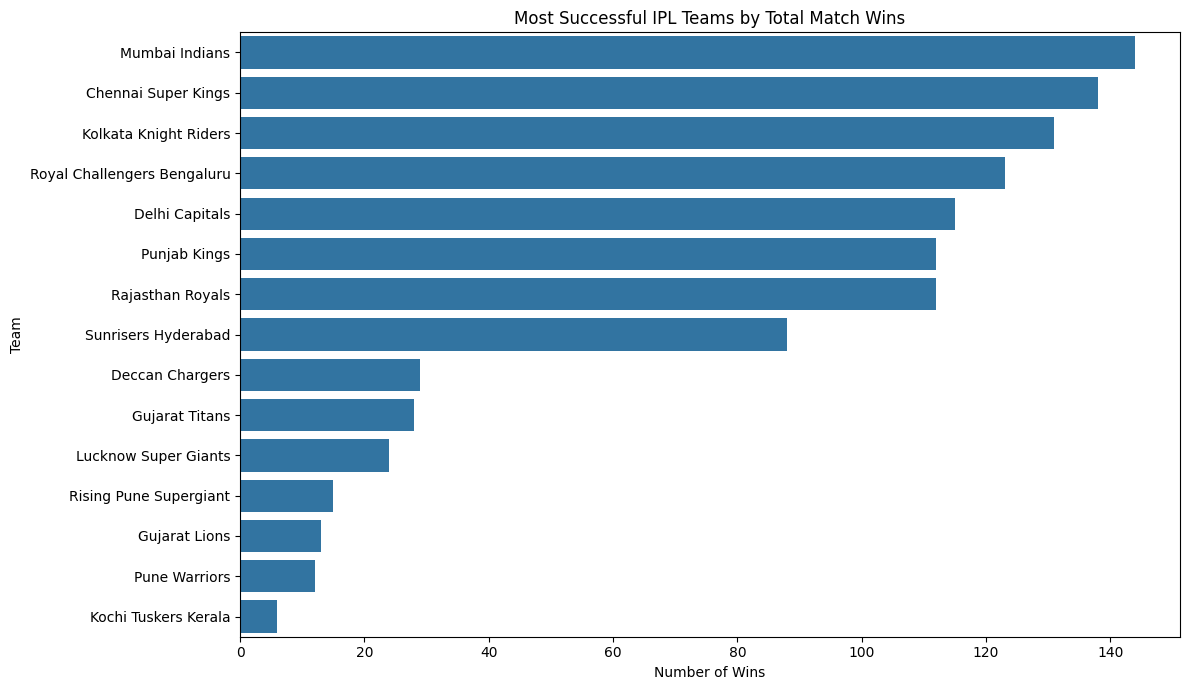

In [46]:
# Visualize total wins by each team

plt.figure(figsize=(12, 7))

sns.barplot(
    x=team_wins.values,
    y=team_wins.index
)

plt.title("Most Successful IPL Teams by Total Match Wins")
plt.xlabel("Number of Wins")
plt.ylabel("Team")

plt.tight_layout()
plt.show()

## 9. 🪙 Toss Analysis


In [47]:
toss_wins = matches['toss_winner'].value_counts()

print(toss_wins)

toss_winner
Mumbai Indians                 143
Delhi Capitals                 130
Kolkata Knight Riders          122
Chennai Super Kings            122
Royal Challengers Bengaluru    121
Rajasthan Royals               120
Punjab Kings                   109
Sunrisers Hyderabad             88
Deccan Chargers                 43
Gujarat Titans                  22
Pune Warriors                   20
Lucknow Super Giants            19
Gujarat Lions                   15
Rising Pune Supergiant          13
Kochi Tuskers Kerala             8
Name: count, dtype: int64


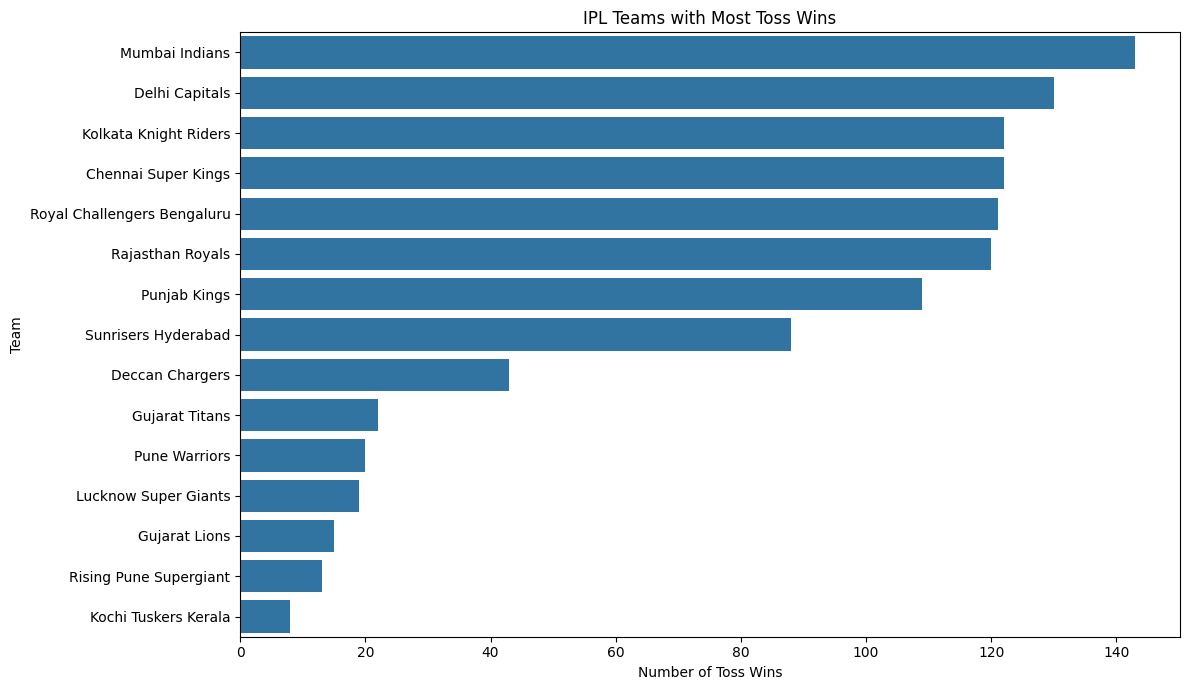

In [48]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=toss_wins.values,
    y=toss_wins.index
)

plt.title("IPL Teams with Most Toss Wins")
plt.xlabel("Number of Toss Wins")
plt.ylabel("Team")

plt.tight_layout()
plt.show()

In [49]:
toss_decision_count = matches['toss_decision'].value_counts()

print(toss_decision_count)

toss_decision
field    704
bat      391
Name: count, dtype: int64


In [50]:
toss_decision_percentage = (
    matches['toss_decision']
    .value_counts(normalize=True) * 100
)

print(toss_decision_percentage)

toss_decision
field    64.292237
bat      35.707763
Name: proportion, dtype: float64


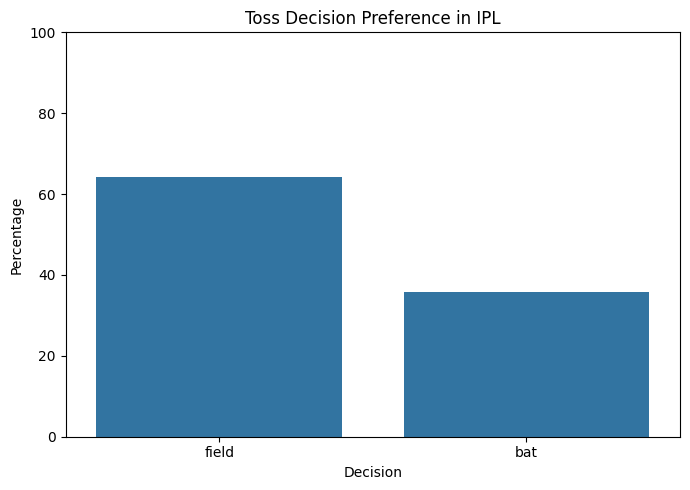

In [51]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=toss_decision_percentage.index,
    y=toss_decision_percentage.values
)

plt.title("Toss Decision Preference in IPL")
plt.xlabel("Decision")
plt.ylabel("Percentage")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

In [52]:
# Check whether toss winner also won the match

toss_match_win = matches[
    matches['toss_winner'] == matches['winner']
].shape[0]

total_completed_matches = matches['winner'].notna().sum()

print("Toss Winner Also Won Match:", toss_match_win)
print("Total Completed Matches:", total_completed_matches)

print(
    "Percentage:",
    round((toss_match_win / total_completed_matches) * 100, 2),
    "%"
)

Toss Winner Also Won Match: 554
Total Completed Matches: 1090
Percentage: 50.83 %


In [53]:
toss_impact = matches[matches['winner'].notna()].copy()

toss_impact['toss_winner_won_match'] = (
    toss_impact['toss_winner'] == toss_impact['winner']
)

toss_result_counts = toss_impact['toss_winner_won_match'].value_counts()

print(toss_result_counts)

toss_winner_won_match
True     554
False    536
Name: count, dtype: int64


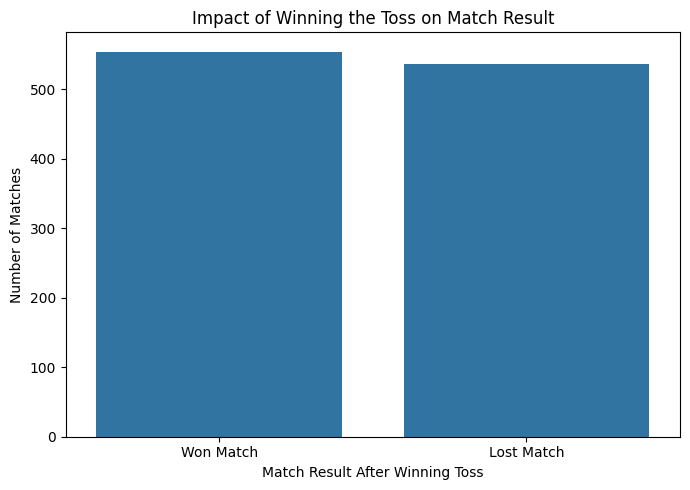

In [54]:
# Convert True/False into meaningful labels
toss_result_counts.index = toss_result_counts.index.map({
    True: 'Won Match',
    False: 'Lost Match'
})

plt.figure(figsize=(7, 5))

sns.barplot(
    x=toss_result_counts.index,
    y=toss_result_counts.values
)

plt.title("Impact of Winning the Toss on Match Result")
plt.xlabel("Match Result After Winning Toss")
plt.ylabel("Number of Matches")

plt.tight_layout()
plt.show()

In [55]:
# Count matches played by each team

team_matches_played = pd.concat([
    matches['team1'],
    matches['team2']
]).value_counts()

print(team_matches_played)

Mumbai Indians                 261
Royal Challengers Bengaluru    255
Delhi Capitals                 252
Kolkata Knight Riders          251
Punjab Kings                   246
Chennai Super Kings            238
Rajasthan Royals               221
Sunrisers Hyderabad            182
Deccan Chargers                 75
Pune Warriors                   46
Gujarat Titans                  45
Lucknow Super Giants            44
Rising Pune Supergiant          30
Gujarat Lions                   30
Kochi Tuskers Kerala            14
Name: count, dtype: int64


In [56]:
# Create team performance DataFrame

team_performance = pd.DataFrame({
    'Matches Played': team_matches_played,
    'Matches Won': team_wins
})

# Calculate win percentage
team_performance['Win Percentage'] = (
    team_performance['Matches Won'] /
    team_performance['Matches Played']
) * 100

# Round the percentage
team_performance['Win Percentage'] = (
    team_performance['Win Percentage'].round(2)
)

# Sort by win percentage
team_performance = team_performance.sort_values(
    by='Win Percentage',
    ascending=False
)

print(team_performance)

                             Matches Played  Matches Won  Win Percentage
Gujarat Titans                           45           28           62.22
Chennai Super Kings                     238          138           57.98
Mumbai Indians                          261          144           55.17
Lucknow Super Giants                     44           24           54.55
Kolkata Knight Riders                   251          131           52.19
Rajasthan Royals                        221          112           50.68
Rising Pune Supergiant                   30           15           50.00
Sunrisers Hyderabad                     182           88           48.35
Royal Challengers Bengaluru             255          123           48.24
Delhi Capitals                          252          115           45.63
Punjab Kings                            246          112           45.53
Gujarat Lions                            30           13           43.33
Kochi Tuskers Kerala                     14        

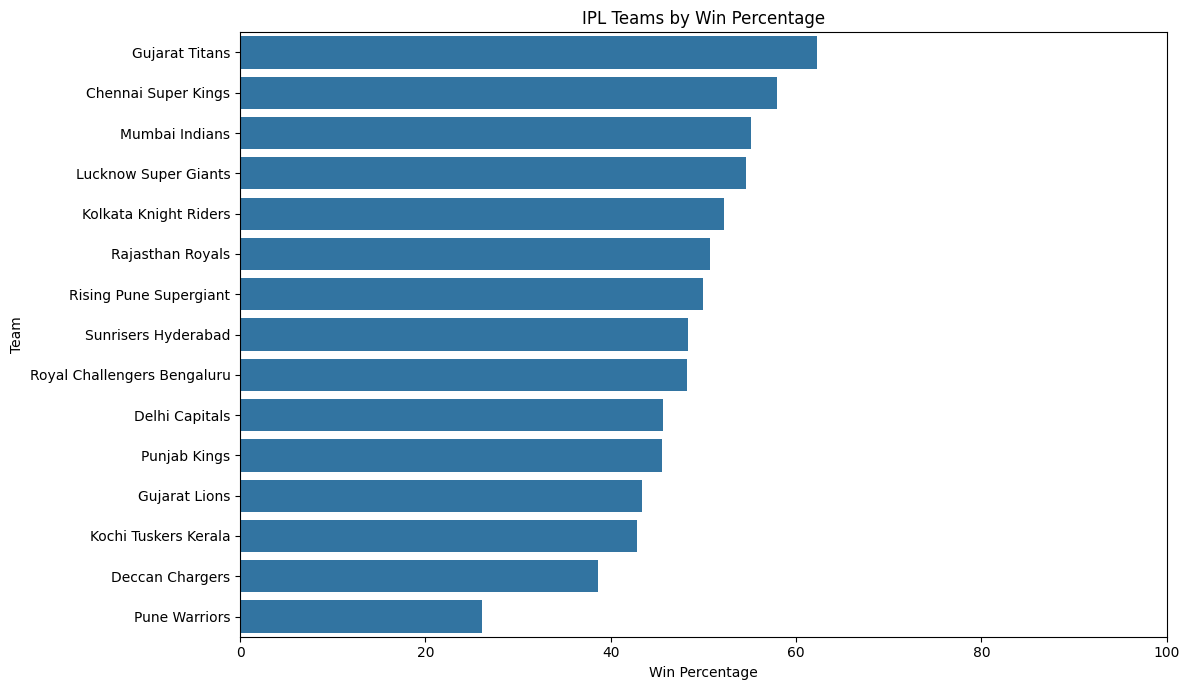

In [57]:
plt.figure(figsize=(12, 7))

sns.barplot(
    x=team_performance['Win Percentage'],
    y=team_performance.index
)

plt.title("IPL Teams by Win Percentage")
plt.xlabel("Win Percentage")
plt.ylabel("Team")

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

## 10. 🏅 Player Analysis


In [58]:
player_of_match_counts = matches['player_of_match'].value_counts()

print(player_of_match_counts.head(10))

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
V Kohli           18
DA Warner         18
MS Dhoni          17
YK Pathan         16
RA Jadeja         16
SR Watson         16
AD Russell        15
Name: count, dtype: int64


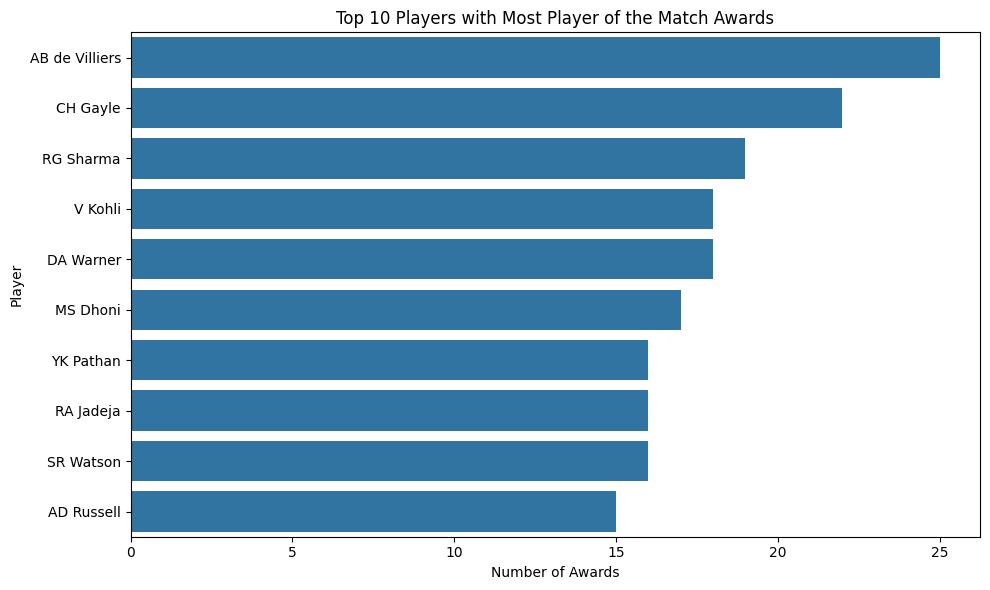

In [59]:
top_10_pom = player_of_match_counts.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_pom.values,
    y=top_10_pom.index
)

plt.title("Top 10 Players with Most Player of the Match Awards")
plt.xlabel("Number of Awards")
plt.ylabel("Player")

plt.tight_layout()
plt.show()

## 11. 🏏 Batting Analysis


In [60]:
# Calculate total runs scored by each batter

top_run_scorers = (
    deliveries.groupby('batter')['batsman_runs']
    .sum()
    .sort_values(ascending=False)
)

print(top_run_scorers.head(10))

batter
V Kohli           8014
S Dhawan          6769
RG Sharma         6630
DA Warner         6567
SK Raina          5536
MS Dhoni          5243
AB de Villiers    5181
CH Gayle          4997
RV Uthappa        4954
KD Karthik        4843
Name: batsman_runs, dtype: int64


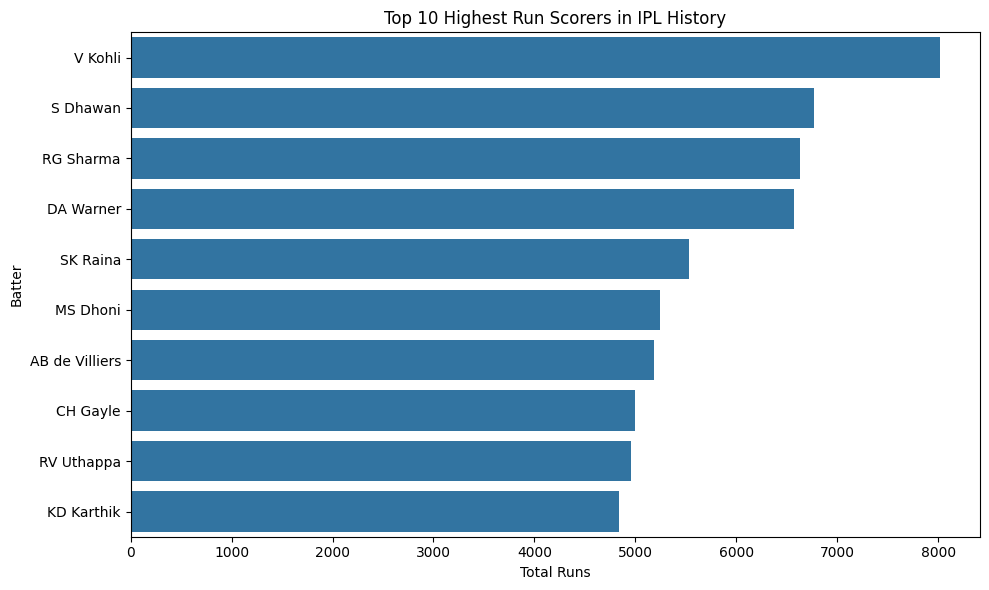

In [61]:
top_10_run_scorers = top_run_scorers.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_run_scorers.values,
    y=top_10_run_scorers.index
)

plt.title("Top 10 Highest Run Scorers in IPL History")
plt.xlabel("Total Runs")
plt.ylabel("Batter")

plt.tight_layout()
plt.show()

In [62]:
# Count total fours hit by each batter

most_fours = (
    deliveries[deliveries['batsman_runs'] == 4]
    .groupby('batter')
    .size()
    .sort_values(ascending=False)
)

print(most_fours.head(10))

batter
S Dhawan        768
V Kohli         708
DA Warner       663
RG Sharma       599
SK Raina        506
G Gambhir       492
RV Uthappa      481
AM Rahane       479
KD Karthik      466
F du Plessis    422
dtype: int64


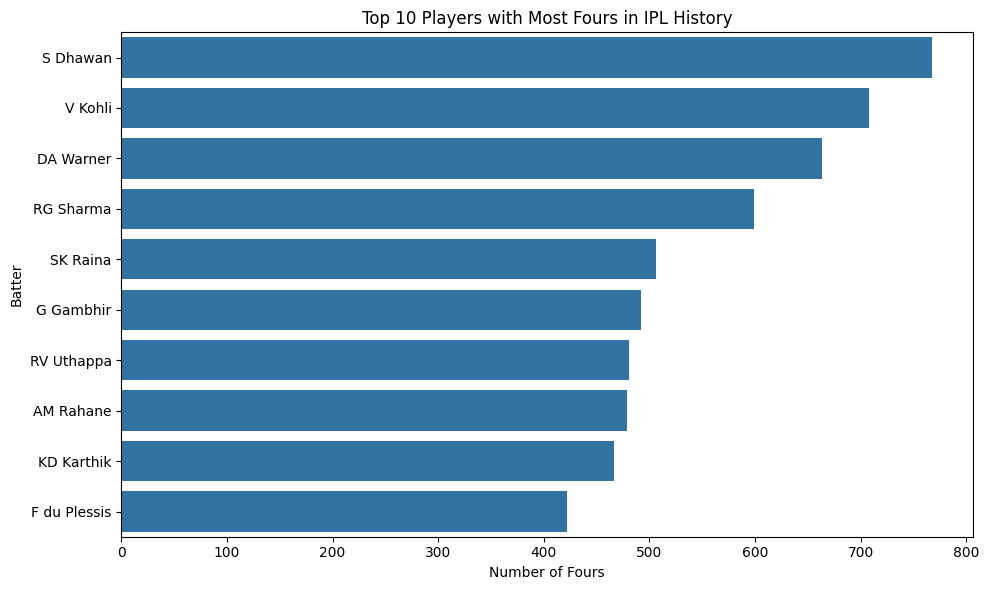

In [63]:
top_10_fours = most_fours.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_fours.values,
    y=top_10_fours.index
)

plt.title("Top 10 Players with Most Fours in IPL History")
plt.xlabel("Number of Fours")
plt.ylabel("Batter")

plt.tight_layout()
plt.show()

In [64]:
# Count total sixes hit by each batter

most_sixes = (
    deliveries[deliveries['batsman_runs'] == 6]
    .groupby('batter')
    .size()
    .sort_values(ascending=False)
)

print(most_sixes.head(10))

batter
CH Gayle          359
RG Sharma         281
V Kohli           273
AB de Villiers    253
MS Dhoni          252
DA Warner         236
KA Pollard        224
AD Russell        209
SV Samson         206
SK Raina          204
dtype: int64


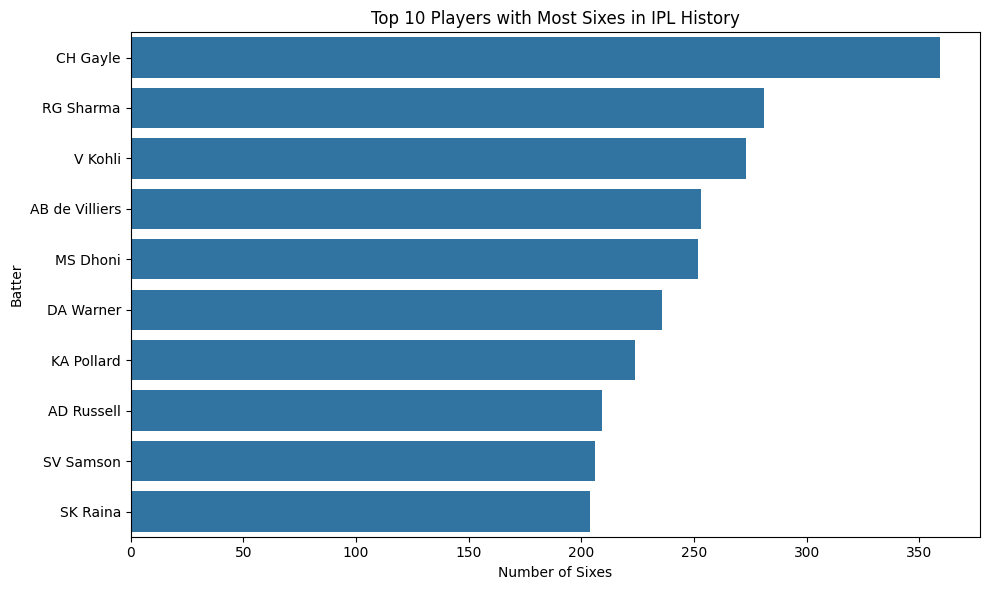

In [65]:
top_10_sixes = most_sixes.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_sixes.values,
    y=top_10_sixes.index
)

plt.title("Top 10 Players with Most Sixes in IPL History")
plt.xlabel("Number of Sixes")
plt.ylabel("Batter")

plt.tight_layout()
plt.show()

In [66]:
# Calculate total runs scored by each batter
batter_runs = deliveries.groupby('batter')['batsman_runs'].sum()

# Calculate total balls faced
balls_faced = deliveries.groupby('batter').size()

# Create batting statistics DataFrame
batting_stats = pd.DataFrame({
    'Runs': batter_runs,
    'Balls Faced': balls_faced
})

# Calculate strike rate
batting_stats['Strike Rate'] = (
    batting_stats['Runs'] / batting_stats['Balls Faced']
) * 100

# Filter batters with at least 500 runs
batting_stats_500 = batting_stats[
    batting_stats['Runs'] >= 500
]

# Sort by strike rate
top_strike_rate = batting_stats_500.sort_values(
    by='Strike Rate',
    ascending=False
)

print(top_strike_rate.head(10))

                Runs  Balls Faced  Strike Rate
batter                                        
PD Salt          653          385   169.610390
TM Head          772          458   168.558952
AD Russell      2488         1515   164.224422
H Klaasen        993          613   161.990212
TH David         659          417   158.033573
SP Narine       1534          984   155.894309
N Pooran        1769         1143   154.768154
LS Livingstone   939          609   154.187192
Rashid Khan      545          355   153.521127
GJ Maxwell      2772         1842   150.488599


In [67]:
balls_faced = deliveries.groupby('batter').size()

In [68]:
# Exclude wide deliveries for accurate balls faced calculation
legal_balls = deliveries[
    deliveries['extras_type'] != 'wides'
]

# Calculate runs
batter_runs = deliveries.groupby('batter')['batsman_runs'].sum()

# Calculate actual balls faced
balls_faced = legal_balls.groupby('batter').size()

# Create batting statistics
batting_stats = pd.DataFrame({
    'Runs': batter_runs,
    'Balls Faced': balls_faced
})

# Calculate strike rate
batting_stats['Strike Rate'] = (
    batting_stats['Runs'] / batting_stats['Balls Faced'] * 100
)

# Keep batters with minimum 500 runs
batting_stats_500 = batting_stats[
    batting_stats['Runs'] >= 500
].copy()

# Sort by strike rate
top_strike_rate = batting_stats_500.sort_values(
    by='Strike Rate',
    ascending=False
)

print(top_strike_rate.head(10))

                Runs  Balls Faced  Strike Rate
batter                                        
PD Salt          653          372   175.537634
AD Russell      2488         1423   174.841883
TM Head          772          444   173.873874
TH David         659          387   170.284238
H Klaasen        993          590   168.305085
SP Narine       1534          925   165.837838
LS Livingstone   939          578   162.456747
N Pooran        1769         1092   161.996337
Rashid Khan      545          337   161.721068
RM Patidar       799          503   158.846918


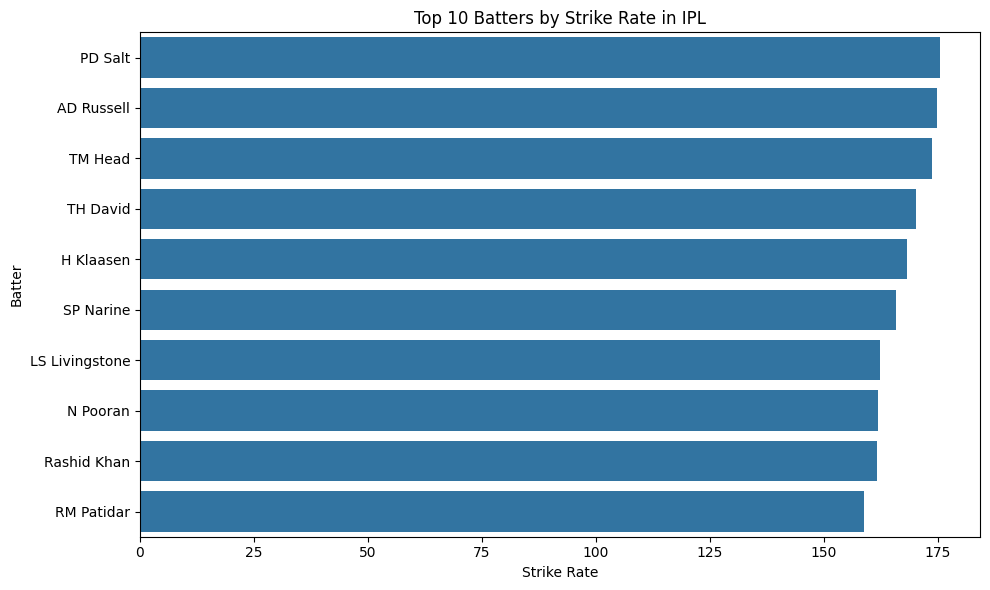

In [69]:
top_10_strike_rate = top_strike_rate.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_strike_rate['Strike Rate'],
    y=top_10_strike_rate.index
)

plt.title("Top 10 Batters by Strike Rate in IPL")
plt.xlabel("Strike Rate")
plt.ylabel("Batter")

plt.tight_layout()
plt.show()

## 12. 🎯 Bowling Analysis


In [70]:
# Dismissal types that do NOT count as a bowler's wicket
non_bowler_wickets = [
    'run out',
    'retired hurt',
    'obstructing the field'
]

# Filter valid bowler wickets
bowler_wickets_data = deliveries[
    (deliveries['is_wicket'] == 1) &
    (~deliveries['dismissal_kind'].isin(non_bowler_wickets))
]

# Count wickets taken by each bowler
top_wicket_takers = (
    bowler_wickets_data
    .groupby('bowler')
    .size()
    .sort_values(ascending=False)
)

print(top_wicket_takers.head(10))

bowler
YS Chahal     205
PP Chawla     192
DJ Bravo      183
B Kumar       181
R Ashwin      180
SP Narine     180
A Mishra      174
SL Malinga    170
JJ Bumrah     168
RA Jadeja     160
dtype: int64


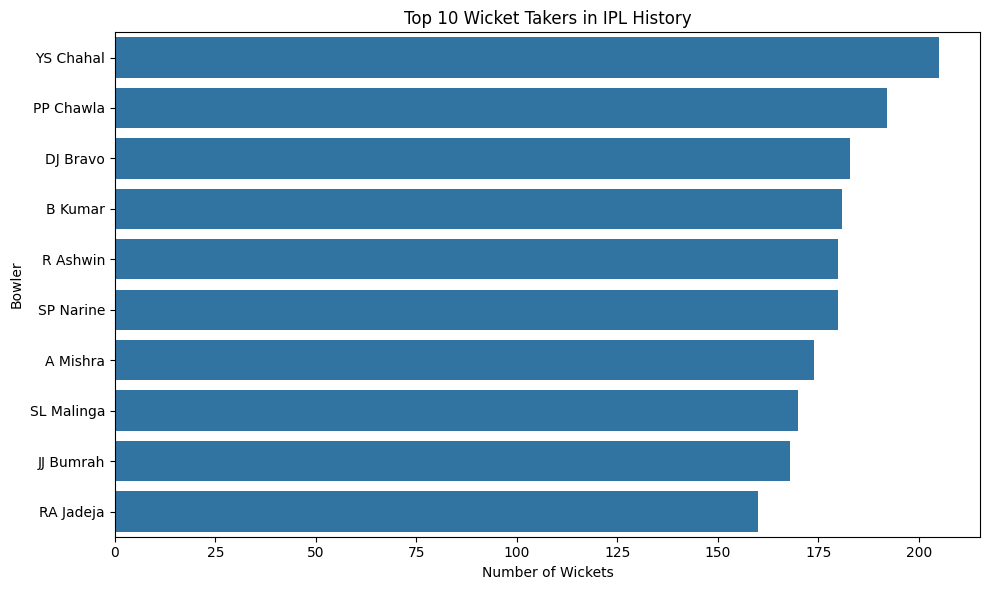

In [71]:
top_10_wicket_takers = top_wicket_takers.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_wicket_takers.values,
    y=top_10_wicket_takers.index
)

plt.title("Top 10 Wicket Takers in IPL History")
plt.xlabel("Number of Wickets")
plt.ylabel("Bowler")

plt.tight_layout()
plt.show()

In [72]:
# Calculate total runs conceded by each bowler
bowler_runs = deliveries.groupby('bowler')['total_runs'].sum()

# Exclude wides and no-balls for calculating legal balls
legal_deliveries = deliveries[
    ~deliveries['extras_type'].isin(['wides', 'noballs'])
]

# Calculate legal balls bowled
bowler_balls = legal_deliveries.groupby('bowler').size()

# Create bowling statistics DataFrame
bowling_stats = pd.DataFrame({
    'Runs Conceded': bowler_runs,
    'Balls Bowled': bowler_balls
})

# Calculate overs
bowling_stats['Overs'] = bowling_stats['Balls Bowled'] / 6

# Calculate economy rate
bowling_stats['Economy Rate'] = (
    bowling_stats['Runs Conceded'] /
    bowling_stats['Overs']
)

# Filter bowlers with minimum 50 overs
bowling_stats_50 = bowling_stats[
    bowling_stats['Overs'] >= 50
].copy()

# Sort by best economy rate
best_economy = bowling_stats_50.sort_values(
    by='Economy Rate',
    ascending=True
)

print(best_economy.head(10))

                  Runs Conceded  Balls Bowled       Overs  Economy Rate
bowler                                                                 
A Kumble                   1089           965  160.833333      6.770984
GD McGrath                  366           324   54.000000      6.777778
SP Narine                  4672          4081  680.166667      6.868905
J Yadav                     447           390   65.000000      6.876923
DL Vettori                  894           777  129.500000      6.903475
M Muralitharan             1765          1528  254.666667      6.930628
RE van der Merwe            515           443   73.833333      6.975169
Rashid Khan                3340          2872  478.666667      6.977716
MJ Santner                  428           366   61.000000      7.016393
J Botha                     818           694  115.666667      7.072046


In [73]:
# Calculate runs conceded by the bowler
# Byes and legbyes are NOT charged to the bowler

bowler_runs_data = deliveries[
    ~deliveries['extras_type'].isin(['byes', 'legbyes'])
]

bowler_runs = (
    bowler_runs_data
    .groupby('bowler')['total_runs']
    .sum()
)

# Legal deliveries exclude wides and no-balls
legal_deliveries = deliveries[
    ~deliveries['extras_type'].isin(['wides', 'noballs'])
]

# Calculate legal balls bowled
bowler_balls = legal_deliveries.groupby('bowler').size()

# Create bowling statistics DataFrame
bowling_stats = pd.DataFrame({
    'Runs Conceded': bowler_runs,
    'Balls Bowled': bowler_balls
})

# Calculate overs
bowling_stats['Overs'] = bowling_stats['Balls Bowled'] / 6

# Calculate economy rate
bowling_stats['Economy Rate'] = (
    bowling_stats['Runs Conceded'] /
    bowling_stats['Overs']
)

# Minimum 50 overs
bowling_stats_50 = bowling_stats[
    bowling_stats['Overs'] >= 50
].copy()

# Sort by best economy
best_economy = bowling_stats_50.sort_values(
    by='Economy Rate',
    ascending=True
)

print(best_economy.head(10))

                  Runs Conceded  Balls Bowled       Overs  Economy Rate
bowler                                                                 
A Kumble                   1058           965  160.833333      6.578238
GD McGrath                  357           324   54.000000      6.611111
M Muralitharan             1706          1528  254.666667      6.698953
SP Narine                  4582          4081  680.166667      6.736584
RE van der Merwe            498           443   73.833333      6.744921
DL Vettori                  879           777  129.500000      6.787645
Rashid Khan                3267          2872  478.666667      6.825209
J Yadav                     445           390   65.000000      6.846154
J Botha                     800           694  115.666667      6.916427
MJ Santner                  422           366   61.000000      6.918033


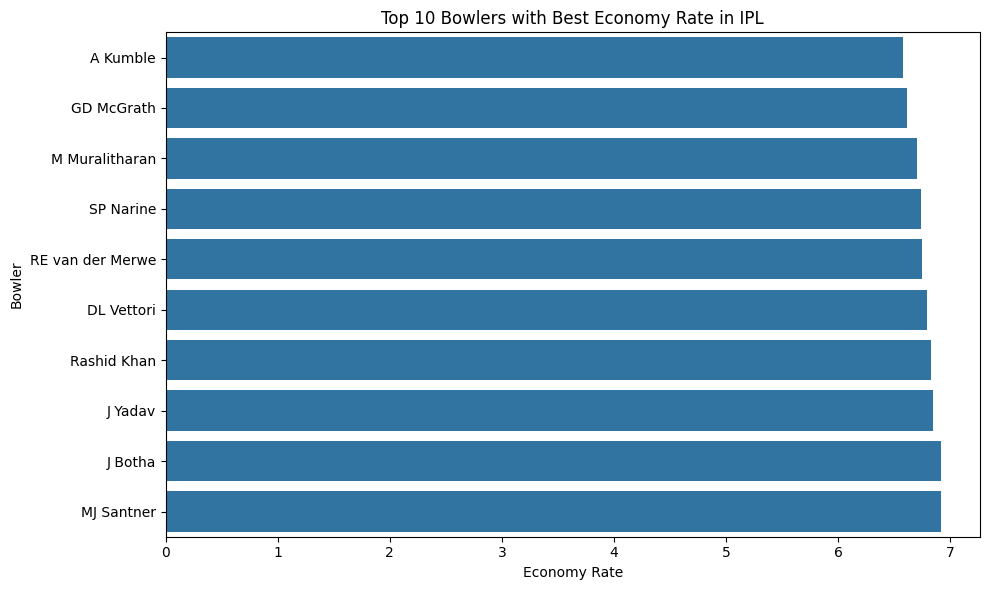

In [74]:
top_10_economy = best_economy.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_economy['Economy Rate'],
    y=top_10_economy.index
)

plt.title("Top 10 Bowlers with Best Economy Rate in IPL")
plt.xlabel("Economy Rate")
plt.ylabel("Bowler")

plt.tight_layout()
plt.show()

In [75]:
# Filter dot balls
dot_balls = deliveries[
    deliveries['total_runs'] == 0
]

# Count dot balls bowled by each bowler
most_dot_balls = (
    dot_balls
    .groupby('bowler')
    .size()
    .sort_values(ascending=False)
)

print(most_dot_balls.head(10))

bowler
B Kumar            1632
SP Narine          1569
R Ashwin           1552
PP Chawla          1325
Harbhajan Singh    1263
JJ Bumrah          1228
RA Jadeja          1216
YS Chahal          1194
UT Yadav           1186
A Mishra           1185
dtype: int64


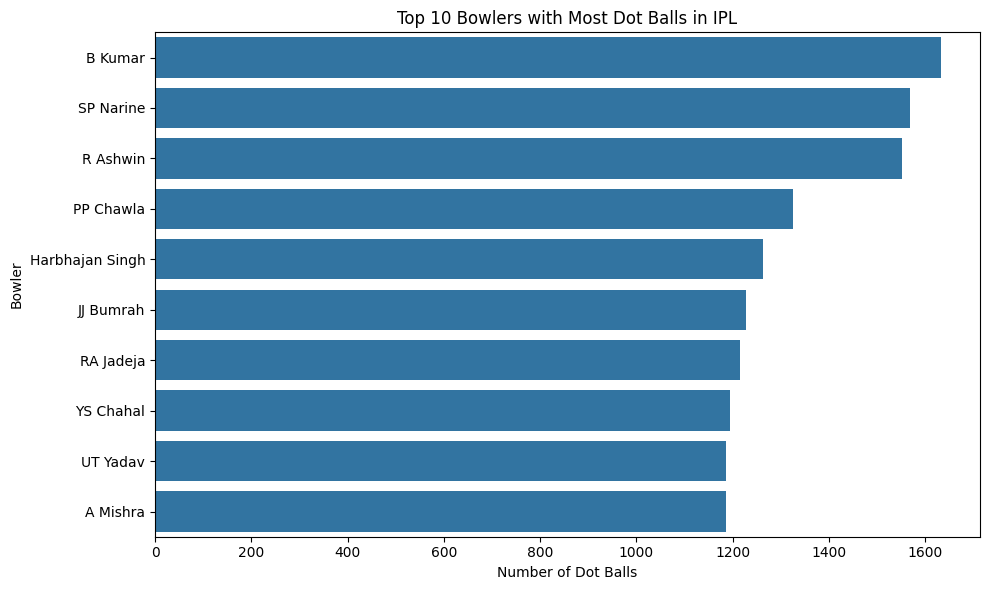

In [76]:
top_10_dot_balls = most_dot_balls.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_dot_balls.values,
    y=top_10_dot_balls.index
)

plt.title("Top 10 Bowlers with Most Dot Balls in IPL")
plt.xlabel("Number of Dot Balls")
plt.ylabel("Bowler")

plt.tight_layout()
plt.show()

## 13. 📈 Team Score Analysis


In [77]:
# Calculate total score for each team in every innings

team_scores = (
    deliveries
    .groupby(['match_id', 'inning', 'batting_team'])['total_runs']
    .sum()
    .reset_index()
)

# Rename column
team_scores = team_scores.rename(
    columns={'total_runs': 'Total Score'}
)

# Sort by highest score
highest_team_scores = team_scores.sort_values(
    by='Total Score',
    ascending=False
)

print(highest_team_scores.head(10))

      match_id  inning                 batting_team  Total Score
2133   1426268       1          Sunrisers Hyderabad          287
2089   1422126       1          Sunrisers Hyderabad          277
2105   1422134       1        Kolkata Knight Riders          272
2143   1426273       1          Sunrisers Hyderabad          266
709     598027       1  Royal Challengers Bengaluru          263
2134   1426268       2  Royal Challengers Bengaluru          262
2158   1426280       2                 Punjab Kings          262
2157   1426280       1        Kolkata Knight Riders          261
2002   1359512       1         Lucknow Super Giants          257
2159   1426281       1               Delhi Capitals          257


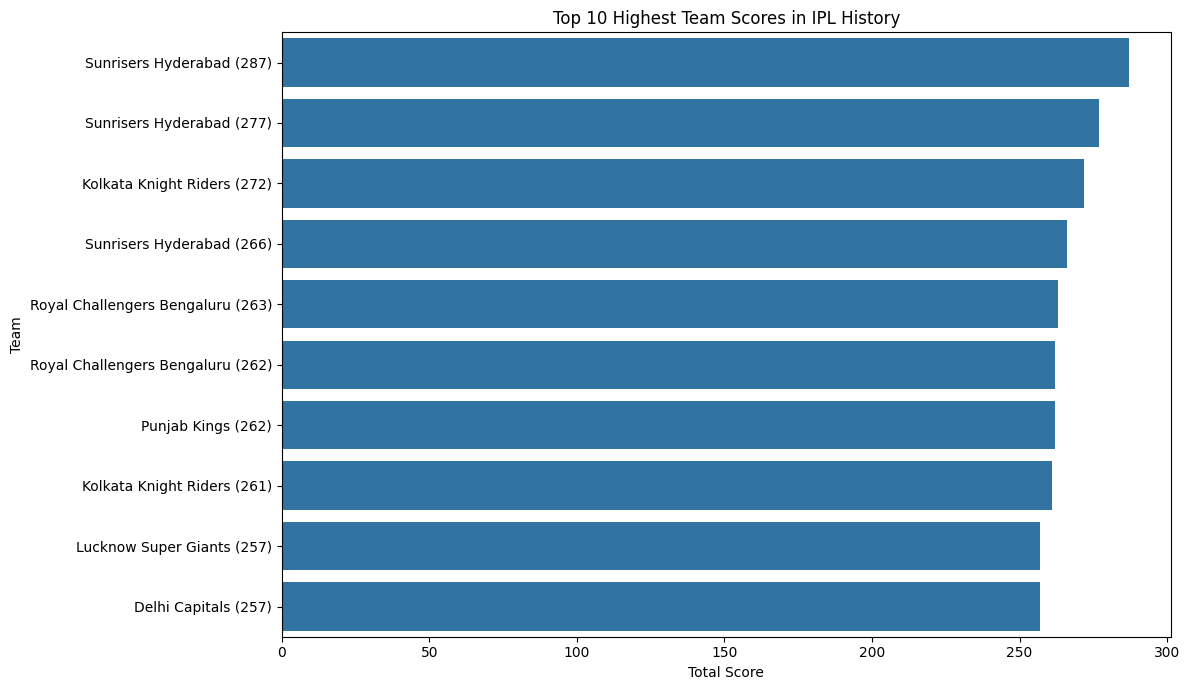

In [78]:
top_10_highest_scores = highest_team_scores.head(10).copy()

# Create labels for visualization
top_10_highest_scores['Label'] = (
    top_10_highest_scores['batting_team'] +
    " (" +
    top_10_highest_scores['Total Score'].astype(str) +
    ")"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_10_highest_scores,
    x='Total Score',
    y='Label'
)

plt.title("Top 10 Highest Team Scores in IPL History")
plt.xlabel("Total Score")
plt.ylabel("Team")

plt.tight_layout()
plt.show()

In [79]:
# Sort team innings scores from lowest to highest

lowest_team_scores = team_scores.sort_values(
    by='Total Score',
    ascending=True
)

print(lowest_team_scores.head(10))

      match_id  inning                 batting_team  Total Score
1033    829813       2  Royal Challengers Bengaluru            2
1532   1216493       3                 Punjab Kings            2
1572   1216512       3          Sunrisers Hyderabad            2
1573   1216512       4        Kolkata Knight Riders            3
1533   1216493       4               Delhi Capitals            3
1584   1216517       3                 Punjab Kings            5
1585   1216517       4               Mumbai Indians            5
1233   1082625       4                Gujarat Lions            6
964     829741       4             Rajasthan Royals            6
1648   1216547       3               Mumbai Indians            7


In [80]:
# Keep only regular innings (1 and 2)
regular_innings_scores = team_scores[
    team_scores['inning'].isin([1, 2])
]

# Sort from lowest to highest
lowest_regular_scores = regular_innings_scores.sort_values(
    by='Total Score',
    ascending=True
)

print(lowest_regular_scores.head(15))

      match_id  inning                 batting_team  Total Score
1033    829813       2  Royal Challengers Bengaluru            2
1503   1178424       2             Rajasthan Royals           41
868     733993       2          Sunrisers Hyderabad           44
1279   1082648       2        Kolkata Knight Riders           48
1217   1082617       2  Royal Challengers Bengaluru           49
87      336025       2          Chennai Super Kings           55
486     501265       1               Delhi Capitals           56
121     392183       2               Delhi Capitals           58
119     392182       2             Rajasthan Royals           58
2046   1359534       2             Rajasthan Royals           59
1295   1136566       2               Delhi Capitals           60
447     501245       2        Kolkata Knight Riders           61
1502   1178424       1  Royal Challengers Bengaluru           62
1133    980989       2        Kolkata Knight Riders           66
1253   1082635       2   

In [81]:
# Merge innings scores with match information

team_scores_with_match = team_scores.merge(
    matches[['id', 'season', 'date', 'venue', 'winner', 'result']],
    left_on='match_id',
    right_on='id',
    how='left'
)

print(team_scores_with_match.head())

   match_id  inning                 batting_team  Total Score      id  \
0    335982       1        Kolkata Knight Riders          222  335982   
1    335982       2  Royal Challengers Bengaluru           82  335982   
2    335983       1          Chennai Super Kings          240  335983   
3    335983       2                 Punjab Kings          207  335983   
4    335984       1             Rajasthan Royals          129  335984   

    season       date                                       venue  \
0  2007/08 2008-04-18                       M Chinnaswamy Stadium   
1  2007/08 2008-04-18                       M Chinnaswamy Stadium   
2  2007/08 2008-04-19  Punjab Cricket Association Stadium, Mohali   
3  2007/08 2008-04-19  Punjab Cricket Association Stadium, Mohali   
4  2007/08 2008-04-19                            Feroz Shah Kotla   

                  winner   result  
0  Kolkata Knight Riders     runs  
1  Kolkata Knight Riders     runs  
2    Chennai Super Kings     runs  
3 

In [82]:
# Calculate number of deliveries in each innings

innings_balls = (
    deliveries
    .groupby(['match_id', 'inning', 'batting_team'])
    .size()
    .reset_index(name='Balls')
)

print(innings_balls.head())

   match_id  inning                 batting_team  Balls
0    335982       1        Kolkata Knight Riders    124
1    335982       2  Royal Challengers Bengaluru    101
2    335983       1          Chennai Super Kings    124
3    335983       2                 Punjab Kings    124
4    335984       1             Rajasthan Royals    122


In [83]:
# Merge balls information with team scores

team_scores_complete = team_scores_with_match.merge(
    innings_balls,
    on=['match_id', 'inning', 'batting_team'],
    how='left'
)

print(team_scores_complete.head())

   match_id  inning                 batting_team  Total Score      id  \
0    335982       1        Kolkata Knight Riders          222  335982   
1    335982       2  Royal Challengers Bengaluru           82  335982   
2    335983       1          Chennai Super Kings          240  335983   
3    335983       2                 Punjab Kings          207  335983   
4    335984       1             Rajasthan Royals          129  335984   

    season       date                                       venue  \
0  2007/08 2008-04-18                       M Chinnaswamy Stadium   
1  2007/08 2008-04-18                       M Chinnaswamy Stadium   
2  2007/08 2008-04-19  Punjab Cricket Association Stadium, Mohali   
3  2007/08 2008-04-19  Punjab Cricket Association Stadium, Mohali   
4  2007/08 2008-04-19                            Feroz Shah Kotla   

                  winner   result  Balls  
0  Kolkata Knight Riders     runs    124  
1  Kolkata Knight Riders     runs    101  
2    Chennai Supe

In [84]:
team_scores_complete[
    (team_scores_complete['match_id'] == 829813)
]

,match_id,inning,batting_team,Total Score,id,season,date,venue,winner,result,Balls
1032,829813,1,Delhi Capitals,187,829813,2015,2015-05-17,M Chinnaswamy Stadium,NaN,no result,123
1033,829813,2,Royal Challengers Bengaluru,2,829813,2015,2015-05-17,M Chinnaswamy Stadium,NaN,no result,7


In [85]:
# Keep only completed matches
completed_scores = team_scores_complete[
    (team_scores_complete['result'] != 'no result') &
    (team_scores_complete['inning'].isin([1, 2]))
].copy()

# Sort from lowest score to highest
lowest_completed_scores = completed_scores.sort_values(
    by='Total Score',
    ascending=True
)

print(
    lowest_completed_scores[
        ['batting_team', 'Total Score', 'season', 'venue', 'result', 'Balls']
    ].head(10)
)

                     batting_team  Total Score   season  \
868           Sunrisers Hyderabad           44     2014   
1279        Kolkata Knight Riders           48     2017   
1217  Royal Challengers Bengaluru           49     2017   
87            Chennai Super Kings           55  2007/08   
119              Rajasthan Royals           58     2009   
121                Delhi Capitals           58     2009   
2046             Rajasthan Royals           59     2023   
1295               Delhi Capitals           60     2018   
447         Kolkata Knight Riders           61     2011   
1133        Kolkata Knight Riders           66     2016   

                               venue   result  Balls  
868                 Feroz Shah Kotla  wickets     30  
1279           M Chinnaswamy Stadium  wickets     35  
1217                    Eden Gardens     runs     62  
87                      Eden Gardens     runs     51  
119                         Newlands     runs     99  
121                 

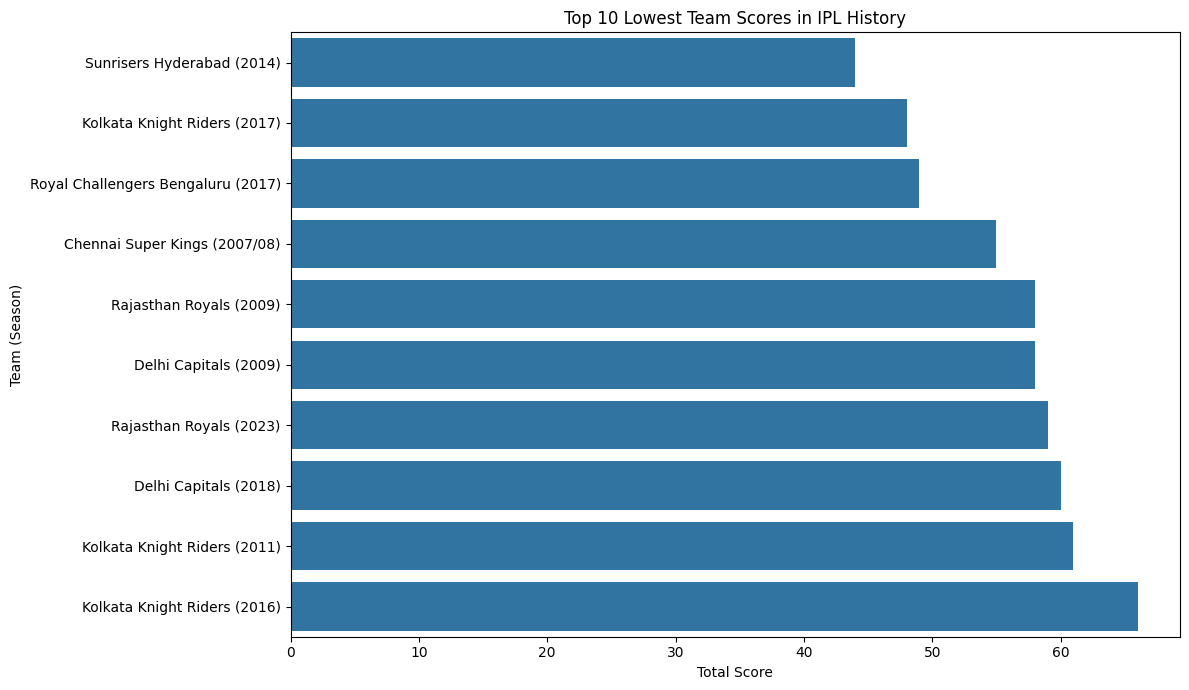

In [86]:
top_10_lowest_scores = lowest_completed_scores.head(10).copy()

top_10_lowest_scores['Label'] = (
    top_10_lowest_scores['batting_team'] +
    " (" +
    top_10_lowest_scores['season'].astype(str) +
    ")"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_10_lowest_scores,
    x='Total Score',
    y='Label'
)

plt.title("Top 10 Lowest Team Scores in IPL History")
plt.xlabel("Total Score")
plt.ylabel("Team (Season)")

plt.tight_layout()
plt.show()

## 14. 🏆 Match Result Analysis


In [87]:
biggest_wins_by_runs = (
    matches[matches['result'] == 'runs']
    .sort_values('result_margin', ascending=False)
    [['season', 'team1', 'team2', 'winner', 'result_margin', 'venue']]
)

print("TOP 10 BIGGEST WINS BY RUNS:\n")
print(biggest_wins_by_runs.head(10))

TOP 10 BIGGEST WINS BY RUNS:

       season                        team1                        team2  \
620      2017               Delhi Capitals               Mumbai Indians   
560      2016  Royal Challengers Bengaluru                Gujarat Lions   
0     2007/08  Royal Challengers Bengaluru        Kolkata Knight Riders   
496      2015  Royal Challengers Bengaluru                 Punjab Kings   
352      2013  Royal Challengers Bengaluru                Pune Warriors   
706      2019          Sunrisers Hyderabad  Royal Challengers Bengaluru   
1009     2023  Royal Challengers Bengaluru             Rajasthan Royals   
236      2011                 Punjab Kings  Royal Challengers Bengaluru   
1039     2024        Kolkata Knight Riders               Delhi Capitals   
55    2007/08               Delhi Capitals             Rajasthan Royals   

                           winner  result_margin  \
620                Mumbai Indians          146.0   
560   Royal Challengers Bengaluru       

In [88]:
biggest_wins_by_wickets = (
    matches[matches['result'] == 'wickets']
    .sort_values('result_margin', ascending=False)
    [['season', 'team1', 'team2', 'winner', 'result_margin', 'venue']]
)

print("TOP 10 BIGGEST WINS BY WICKETS:\n")
print(biggest_wins_by_wickets.head(10))

TOP 10 BIGGEST WINS BY WICKETS:

      season                        team1                        team2  \
12   2007/08               Mumbai Indians              Deccan Chargers   
811  2020/21               Mumbai Indians          Sunrisers Hyderabad   
60      2009               Delhi Capitals                 Punjab Kings   
796  2020/21          Chennai Super Kings               Mumbai Indians   
482     2015               Delhi Capitals  Royal Challengers Bengaluru   
831     2021             Rajasthan Royals  Royal Challengers Bengaluru   
124  2009/10  Royal Challengers Bengaluru             Rajasthan Royals   
531     2016                Gujarat Lions          Sunrisers Hyderabad   
332     2013                 Punjab Kings          Chennai Super Kings   
317     2012             Rajasthan Royals               Mumbai Indians   

                          winner  result_margin  \
12               Deccan Chargers           10.0   
811          Sunrisers Hyderabad           10.0   

## 15. ⚡ Advanced Phase Analysis


In [89]:
# Filter powerplay deliveries (first 6 overs)
powerplay_data = deliveries[
    deliveries['over'] < 6
]

# Calculate total runs scored by each batting team in powerplay
powerplay_runs = (
    powerplay_data
    .groupby('batting_team')['total_runs']
    .sum()
    .sort_values(ascending=False)
)

print("TOTAL POWERPLAY RUNS BY TEAM:\n")
print(powerplay_runs)

TOTAL POWERPLAY RUNS BY TEAM:

batting_team
Mumbai Indians                 12225
Delhi Capitals                 12069
Kolkata Knight Riders          11941
Punjab Kings                   11795
Royal Challengers Bengaluru    11795
Chennai Super Kings            10991
Rajasthan Royals               10226
Sunrisers Hyderabad             8937
Deccan Chargers                 3417
Gujarat Titans                  2184
Lucknow Super Giants            2080
Pune Warriors                   1895
Gujarat Lions                   1559
Rising Pune Supergiant          1423
Kochi Tuskers Kerala             680
Name: total_runs, dtype: int64


In [90]:
# Calculate total powerplay runs for each team
powerplay_runs = (
    powerplay_data
    .groupby('batting_team')['total_runs']
    .sum()
)

# Exclude wides and no-balls for legal balls
powerplay_legal_balls = powerplay_data[
    ~powerplay_data['extras_type'].isin(['wides', 'noballs'])
]

# Calculate legal balls faced by each team
powerplay_balls = (
    powerplay_legal_balls
    .groupby('batting_team')
    .size()
)

# Create Powerplay Statistics DataFrame
powerplay_stats = pd.DataFrame({
    'Runs': powerplay_runs,
    'Balls': powerplay_balls
})

# Calculate overs
powerplay_stats['Overs'] = powerplay_stats['Balls'] / 6

# Calculate Run Rate
powerplay_stats['Run Rate'] = (
    powerplay_stats['Runs'] / powerplay_stats['Overs']
)

# Sort by run rate
powerplay_stats = powerplay_stats.sort_values(
    by='Run Rate',
    ascending=False
)

print(powerplay_stats)

                              Runs  Balls        Overs  Run Rate
batting_team                                                    
Gujarat Lions                 1559   1086   181.000000  8.613260
Sunrisers Hyderabad           8937   6561  1093.500000  8.172840
Kochi Tuskers Kerala           680    504    84.000000  8.095238
Gujarat Titans                2184   1621   270.166667  8.083899
Punjab Kings                 11795   8879  1479.833333  7.970492
Delhi Capitals               12069   9088  1514.666667  7.968090
Kolkata Knight Riders        11941   9049  1508.166667  7.917560
Rising Pune Supergiant        1423   1080   180.000000  7.905556
Lucknow Super Giants          2080   1584   264.000000  7.878788
Mumbai Indians               12225   9420  1570.000000  7.786624
Rajasthan Royals             10226   7917  1319.500000  7.749905
Chennai Super Kings          10991   8537  1422.833333  7.724728
Royal Challengers Bengaluru  11795   9162  1527.000000  7.724296
Deccan Chargers          

In [91]:
# Filter death overs (Overs 16 to 20)
death_overs_data = deliveries[
    deliveries['over'] >= 16
]

# Calculate total runs scored by each team
death_overs_runs = (
    death_overs_data
    .groupby('batting_team')['total_runs']
    .sum()
    .sort_values(ascending=False)
)

print("TOTAL DEATH OVER RUNS BY TEAM:\n")
print(death_overs_runs)

TOTAL DEATH OVER RUNS BY TEAM:

batting_team
Mumbai Indians                 9598
Chennai Super Kings            9061
Royal Challengers Bengaluru    9028
Punjab Kings                   8274
Delhi Capitals                 8184
Kolkata Knight Riders          8053
Rajasthan Royals               7281
Sunrisers Hyderabad            6237
Deccan Chargers                2539
Gujarat Titans                 1823
Lucknow Super Giants           1718
Pune Warriors                  1360
Rising Pune Supergiant          998
Gujarat Lions                   921
Kochi Tuskers Kerala            337
Name: total_runs, dtype: int64


In [92]:
# Calculate total death-over runs
death_runs = (
    death_overs_data
    .groupby('batting_team')['total_runs']
    .sum()
)

# Keep only legal deliveries
death_legal_balls = death_overs_data[
    ~death_overs_data['extras_type'].isin(['wides', 'noballs'])
]

# Calculate balls faced in death overs
death_balls = (
    death_legal_balls
    .groupby('batting_team')
    .size()
)

# Create Death Overs Statistics DataFrame
death_stats = pd.DataFrame({
    'Runs': death_runs,
    'Balls': death_balls
})

# Calculate overs
death_stats['Overs'] = death_stats['Balls'] / 6

# Calculate run rate
death_stats['Run Rate'] = (
    death_stats['Runs'] / death_stats['Overs']
)

# Sort by highest run rate
death_stats = death_stats.sort_values(
    by='Run Rate',
    ascending=False
)

print(death_stats)

                             Runs  Balls       Overs   Run Rate
batting_team                                                   
Gujarat Titans               1823    962  160.333333  11.370062
Lucknow Super Giants         1718    938  156.333333  10.989339
Chennai Super Kings          9061   5003  833.833333  10.866680
Royal Challengers Bengaluru  9028   5037  839.500000  10.754020
Mumbai Indians               9598   5386  897.666667  10.692165
Rising Pune Supergiant        998    576   96.000000  10.395833
Kolkata Knight Riders        8053   4748  791.333333  10.176495
Delhi Capitals               8184   4891  815.166667  10.039665
Rajasthan Royals             7281   4414  735.666667   9.897145
Sunrisers Hyderabad          6237   3788  631.333333   9.879092
Punjab Kings                 8274   5077  846.166667   9.778215
Deccan Chargers              2539   1600  266.666667   9.521250
Gujarat Lions                 921    581   96.833333   9.511188
Kochi Tuskers Kerala          337    230

# 🔍 Key Insights from IPL Exploratory Data Analysis

1. **Mumbai Indians** recorded the highest number of match victories in the dataset, making them one of the most successful IPL teams.

2. **Gujarat Titans** achieved the highest win percentage among teams with a significant number of matches, although newer teams have a smaller sample size compared to older franchises.

3. Teams chose to **field after winning the toss more frequently** than batting first, showing a strong preference for chasing.

4. Winning the toss did not guarantee winning the match. The toss winner won approximately **50.83% of completed matches**.

5. **AB de Villiers** received the highest number of Player of the Match awards in the dataset.

6. **Virat Kohli** emerged as the highest run scorer in IPL history based on the dataset.

7. **Shikhar Dhawan** faced the highest number of deliveries, highlighting his consistency and longevity as a top-order batter.

8. **Chris Gayle** hit the highest number of sixes, demonstrating his dominance as one of the most powerful hitters in IPL history.

9. Among batters with at least 500 runs, **PD Salt** recorded the highest batting strike rate in the dataset.

10. **Yuzvendra Chahal** emerged as the leading wicket-taker in the IPL dataset.

11. **Anil Kumble** recorded the best bowling economy rate among bowlers who bowled at least 50 overs.

12. **Bhuvneshwar Kumar** bowled the highest number of dot balls, demonstrating his ability to consistently build pressure on batters.

13. **Sunrisers Hyderabad** recorded the highest team innings score of **287 runs**, reflecting the increasing impact of aggressive batting in modern IPL seasons.

14. The lowest meaningful completed innings score in the dataset was **44 runs by Sunrisers Hyderabad**.

15. **Mumbai Indians' 146-run victory** was the biggest victory by runs in the dataset.

16. Several teams achieved the maximum possible **10-wicket victory**, showing complete dominance while chasing targets.

17. Powerplay scoring patterns showed that teams increasingly focused on aggressive batting during the first six overs.

18. Death-over scoring rates were significantly higher than traditional phases of the innings, highlighting the importance of finishers and aggressive batting in the final overs.

# 📝 Conclusion

This Exploratory Data Analysis (EDA) of the Indian Premier League (IPL) dataset provides valuable insights into the evolution of teams, players, batting performance, bowling performance, and match outcomes across multiple IPL seasons.

The analysis shows that team success is influenced by several factors, including consistent match performance, effective bowling, aggressive batting, and strategic decision-making. Mumbai Indians emerged as the team with the highest number of victories in the dataset, while Gujarat Titans demonstrated an impressive win percentage among the teams analyzed.

The toss analysis revealed that teams preferred to field first more often, but winning the toss did not significantly guarantee winning the match. This highlights that overall team performance plays a more important role than the toss outcome.

From the batting analysis, Virat Kohli emerged as the highest run scorer, while Chris Gayle dominated the six-hitting statistics. Modern IPL cricket also showed the importance of aggressive scoring, especially during the powerplay and death overs.

The bowling analysis highlighted the contributions of leading wicket-takers such as Yuzvendra Chahal, economical bowlers such as Anil Kumble, and pressure-building bowlers such as Bhuvneshwar Kumar.

Overall, this project demonstrates how Exploratory Data Analysis can transform raw cricket data into meaningful insights. The findings highlight the evolution of IPL cricket towards more aggressive batting strategies while also emphasizing the continued importance of efficient bowling and consistent team performance.

This analysis provides a strong foundation for future work such as predictive modeling, player performance prediction, match outcome prediction, and interactive cricket dashboards.